In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# THE dataset, read from the CSV that 01_eda.ipynb produced.
# No second sns.load_dataset call anywhere in the module -- this satisfies
# the "loaded from network/cache exactly once" rule.
df = pd.read_csv("titanic.csv")
print(f"Loaded titanic.csv -- shape: {df.shape}")
df.head()

Loaded titanic.csv -- shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
drop_cols = ["alive", "class", "who", "adult_male", "deck", "embark_town", "alone"]
data = df.drop(columns=drop_cols)

X = data.drop(columns=["survived"])
y = data["survived"]

print("Features used:", list(X.columns))
print("Target: survived")
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Features used: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Target: survived

X shape: (891, 7), y shape: (891,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows\n")

print("Class balance — full data:")
print(y.value_counts(normalize=True).mul(100).round(1).to_string())
print("\nClass balance — train:")
print(y_train.value_counts(normalize=True).mul(100).round(1).to_string())
print("\nClass balance — test:")
print(y_test.value_counts(normalize=True).mul(100).round(1).to_string())

Train: 712 rows | Test: 179 rows

Class balance — full data:
survived
0    61.6
1    38.4

Class balance — train:
survived
0    61.7
1    38.3

Class balance — test:
survived
0    61.5
1    38.5


Split 80/20 with `stratify=y` and `random_state=42` for reproducibility.

Stratification matters here because the target is imbalanced — 61.6% died vs 38.4%
survived (measured in Task 1). A plain random split could, by chance, under-represent
the minority class in the test set, making metrics like recall unstable and
unreliable. Stratifying forces both splits to preserve the ~62/38 ratio, so the test
set is a faithful miniature of the full data:

| Split | Died | Survived |
|---|---|---|
| Full | 61.6% | 38.4% |
| Train | 61.7% | 38.3% |
| Test | 61.5% | 38.5% |

The split is done **before any preprocessing** so that no test-set information leaks
into imputation, encoding, or scaling.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

print("Preprocessor built.")
print("Numeric (impute+scale):", numeric_features)
print("Categorical (impute+one-hot):", categorical_features)

Preprocessor built.
Numeric (impute+scale): ['age', 'sibsp', 'parch', 'fare']
Categorical (impute+one-hot): ['pclass', 'sex', 'embarked']


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
}

pipelines = {}
for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", estimator),
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


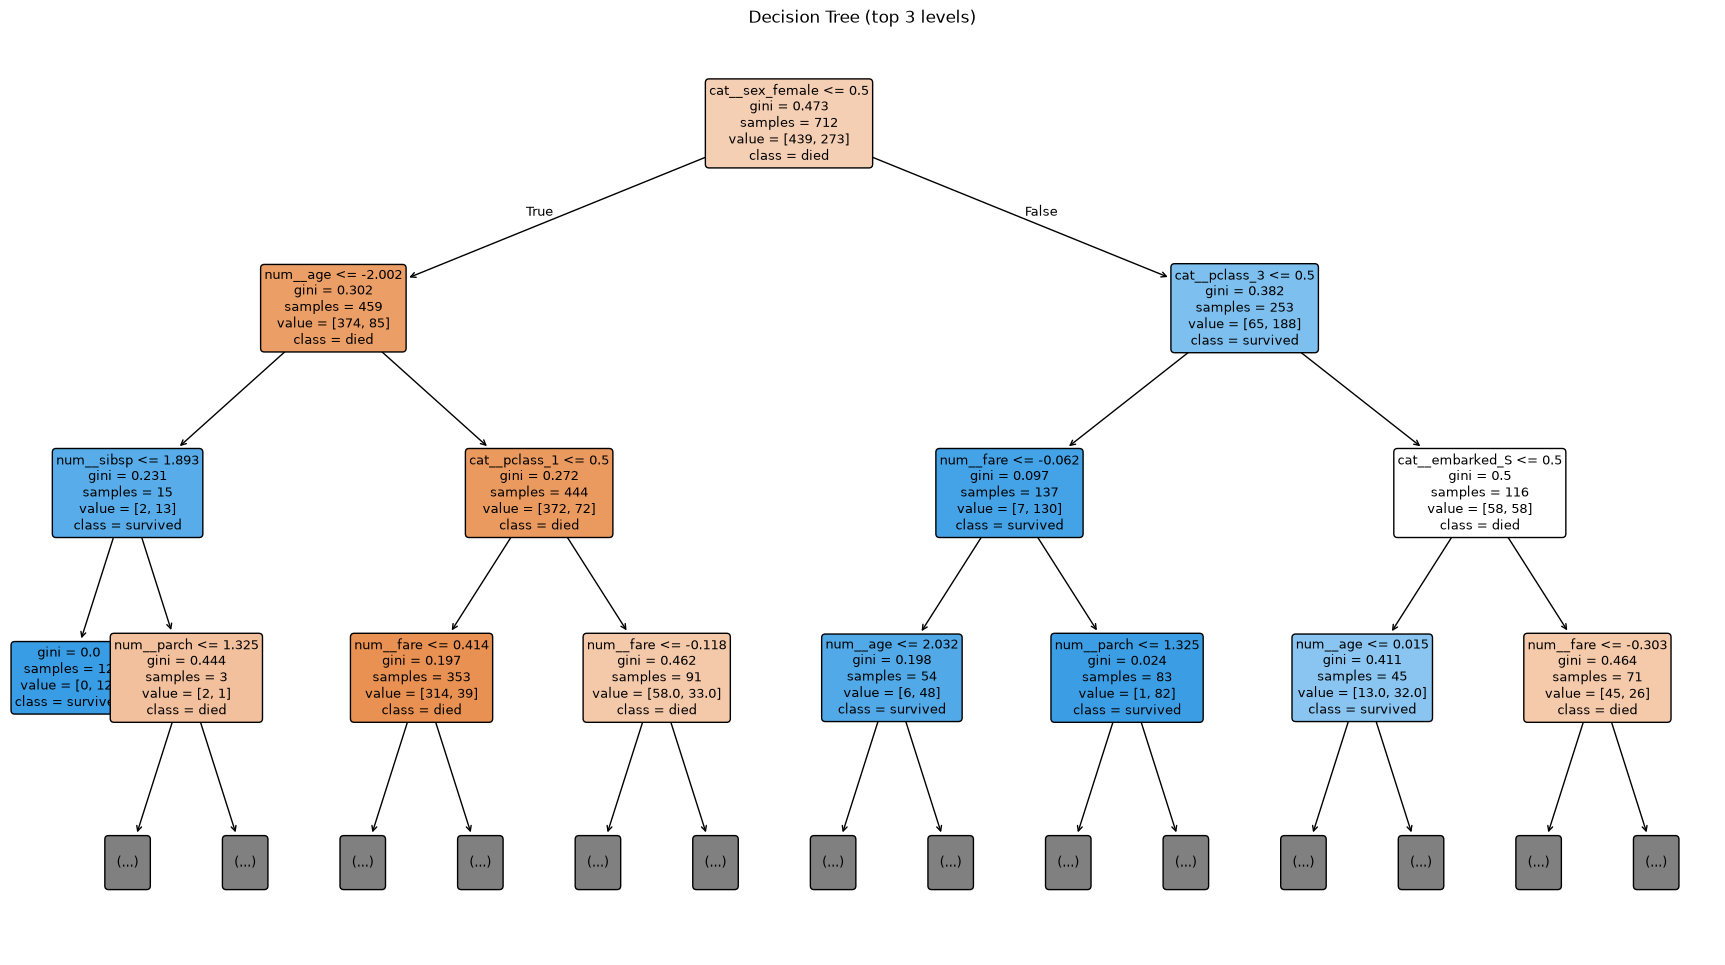

In [6]:
from sklearn.tree import plot_tree

feat_names = pipelines["Decision Tree"].named_steps["preprocess"].get_feature_names_out()

dt_model = pipelines["Decision Tree"].named_steps["model"]

plt.figure(figsize=(22, 12))
plot_tree(
    dt_model,
    feature_names=feat_names,
    class_names=["died", "survived"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Decision Tree (top 3 levels)")
plt.savefig("plots_decision_tree.png", dpi=100, bbox_inches="tight")
plt.show()

Trained Logistic Regression, Decision Tree, and Random Forest, each wrapped in the
same preprocessing pipeline so all three see identical, leak-free inputs.

The decision tree's structure confirms the EDA findings:

- **Root split is `cat__sex_female <= 0.5`** — the tree, given every feature, picks
  sex as the single most decisive split, matching the 74% vs 18.9% survival gap.
- **Male branch (left)** → predominantly `died` (374 of 459 males), then refined by
  age (young boys fare better) and class.
- **Female branch (right)** → predominantly `survived` (188 of 253 females), then
  refined by class (third-class women fare worst).

Feature names carry `num__` / `cat__` prefixes from the `ColumnTransformer` branches;
`sex_female` is the one-hot-encoded column. The plot shows the top 3 levels only —
the full trained tree is deeper but unreadable when drawn in full.

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

rows = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall":    round(recall_score(y_test, y_pred), 3),
        "F1":        round(f1_score(y_test, y_pred), 3),
        "AUC":       round(roc_auc_score(y_test, y_proba), 3),
    })

results = pd.DataFrame(rows).set_index("Model")
print(results.to_string())

                     Accuracy  Precision  Recall     F1    AUC
Model                                                         
Logistic Regression     0.804      0.793   0.667  0.724  0.843
Decision Tree           0.804      0.766   0.710  0.737  0.781
Random Forest           0.793      0.767   0.667  0.713  0.829


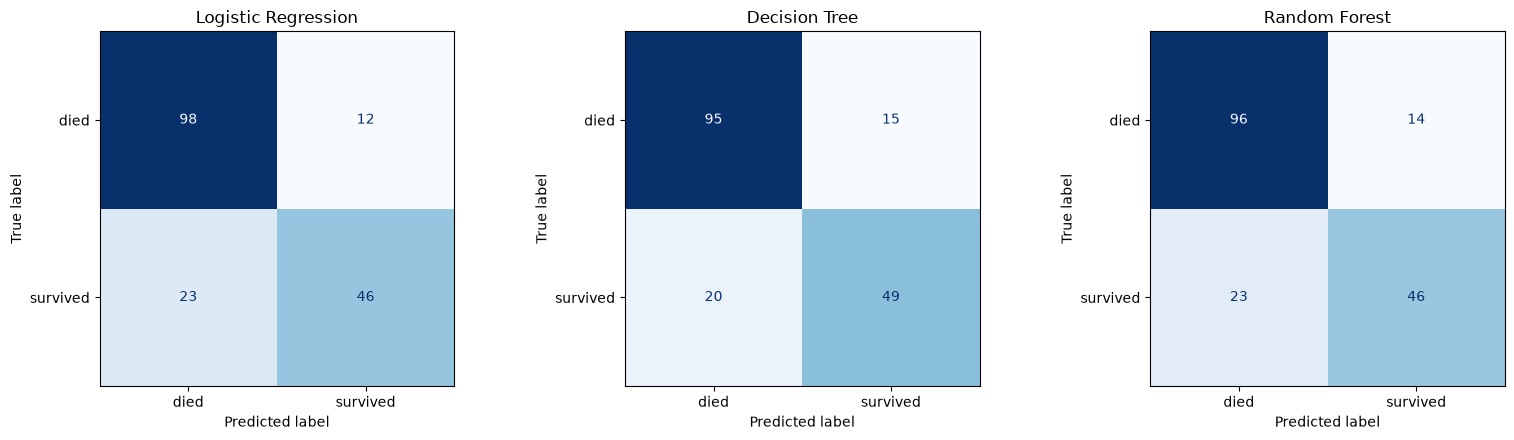

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("plots_confusion_matrices.png", dpi=100, bbox_inches="tight")
plt.show()

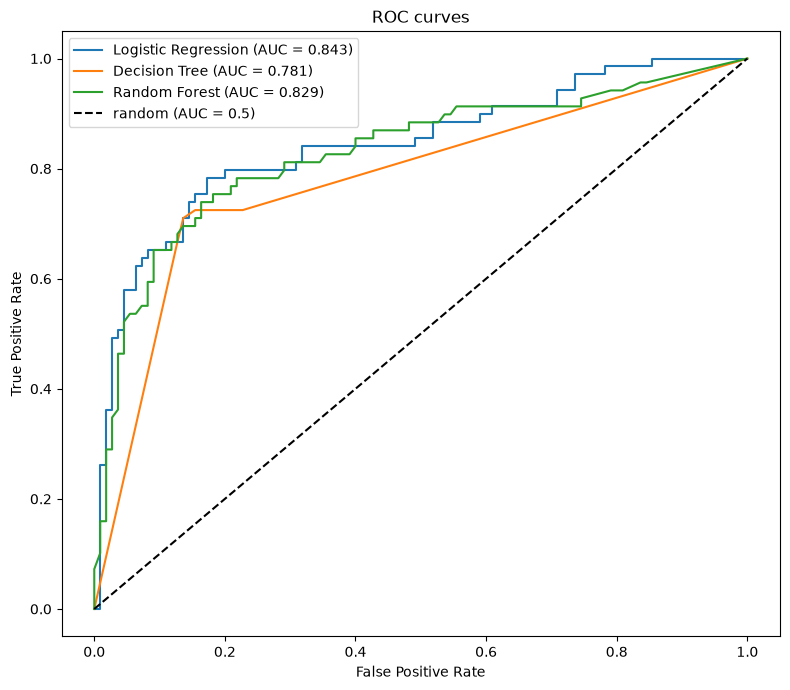

In [9]:
plt.figure(figsize=(8, 7))
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.tight_layout()
plt.savefig("plots_roc_curves.png", dpi=100, bbox_inches="tight")
plt.show()

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.804 | 0.793 | 0.667 | 0.724 | 0.843 |
| Decision Tree | 0.804 | 0.766 | 0.710 | 0.737 | 0.781 |
| Random Forest | 0.793 | 0.767 | 0.667 | 0.713 | 0.829 |

All three beat the majority-class baseline (61.5% "predict everyone died"), and none
show signs of leakage. The race is close, and the leader depends on the metric:

- **Logistic Regression** has the best **AUC (0.843)** and **precision (0.793)** — the
  strongest at *ranking* passengers by survival likelihood, and least prone to false
  alarms. Its ROC curve hugs the top-left corner most tightly.
- **Decision Tree** has the best **recall (0.710)** and **F1 (0.737)** — it catches the
  most actual survivors (49 of 69), but its AUC (0.781) is weakest, because a single
  tree produces coarse probability estimates.
- **Random Forest** is competitive but edged out on this small dataset, where it
  didn't gain its usual ensemble advantage.

The confusion matrices show the precision/recall trade-off concretely: Logistic
Regression misses 23 survivors but raises only 12 false alarms, while the Decision
Tree misses fewer (20) at the cost of more false alarms (15). AUC and F1 disagree on
the winner — LR wins on threshold-independent ranking, the Tree on balance at the
default threshold — so the final deployment choice (Task 14) weighs which error type
matters more.

In [10]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("Training class balance:")
print(y_train.value_counts().to_string())
print(f"Ratio -> {y_train.value_counts(normalize=True).mul(100).round(1).to_dict()}\n")

def evaluate(pipe, label):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    return {
        "Variant":   label,
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall":    round(recall_score(y_test, y_pred), 3),
        "F1":        round(f1_score(y_test, y_pred), 3),
    }

pipe_base = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

pipe_weighted = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42,
                                 class_weight="balanced")),
])

pipe_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

imb_results = pd.DataFrame([
    evaluate(pipe_base,     "(a) baseline"),
    evaluate(pipe_weighted, "(b) class_weight='balanced'"),
    evaluate(pipe_smote,    "(c) SMOTE (train only)"),
]).set_index("Variant")

print(imb_results.to_string())

Training class balance:
survived
0    439
1    273
Ratio -> {0: 61.7, 1: 38.3}

                             Precision  Recall     F1
Variant                                              
(a) baseline                     0.793   0.667  0.724
(b) class_weight='balanced'      0.740   0.783  0.761
(c) SMOTE (train only)           0.730   0.783  0.755


Training set is imbalanced: 439 died vs 273 survived (61.7% / 38.3%). Retrained
Logistic Regression three ways; SMOTE was applied to the **training fold only** via
an `imblearn` pipeline, so the test set is never oversampled.

| Variant | Precision | Recall | F1 |
|---|---|---|---|
| Baseline | 0.793 | 0.667 | 0.724 |
| `class_weight='balanced'` | 0.740 | 0.783 | 0.761 |
| SMOTE (train only) | 0.730 | 0.783 | 0.755 |

**Conclusion:** The baseline maximizes precision but has the weakest recall — biased
toward the majority "died" class, it misses a third of real survivors. Both rebalancing
methods lift recall from 0.667 to 0.783, trading a small precision drop for catching
more survivors, and both improve F1 overall. `class_weight='balanced'` performed best
(F1 = 0.761) and is also the simpler, cheaper option since it reweights the loss rather
than synthesizing new samples. If recall on survivors is the priority, it is the
strongest choice here.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth":    [4, 6, 8, None],
    "model__max_features": ["sqrt", "log2"],
}

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Best parameters:")
for k, v in grid.best_params_.items():
    print(f"  {k} = {v}")
print(f"\nBest cross-validated F1: {grid.best_score_:.3f}")

Best parameters:
  model__max_depth = 8
  model__max_features = sqrt
  model__n_estimators = 300

Best cross-validated F1: 0.753


In [12]:
best = grid.best_params_
X_train_prep = preprocessor.fit_transform(X_train)

rf_oob = RandomForestClassifier(
    n_estimators = best["model__n_estimators"],
    max_depth    = best["model__max_depth"],
    max_features = best["model__max_features"],
    oob_score    = True,
    bootstrap    = True,
    random_state = 42,
)
rf_oob.fit(X_train_prep, y_train)

print(f"Tuned RF OOB score: {rf_oob.oob_score_:.3f}")

y_pred_tuned = grid.best_estimator_.predict(X_test)
print(f"Tuned RF test F1:   {f1_score(y_test, y_pred_tuned):.3f}")
print(f"Tuned RF test acc:  {accuracy_score(y_test, y_pred_tuned):.3f}")

Tuned RF OOB score: 0.823
Tuned RF test F1:   0.730
Tuned RF test acc:  0.810


Ran `GridSearchCV` over the Random Forest with 5-fold CV, optimizing F1, across
`n_estimators` {100, 200, 300}, `max_depth` {4, 6, 8, None}, and `max_features`
{sqrt, log2} — 24 combinations × 5 folds = 120 fits.

**Best parameters:** `max_depth=8`, `max_features='sqrt'`, `n_estimators=300`
**Best cross-validated F1:** 0.753
**OOB score:** 0.823 (from a forest rebuilt with `oob_score=True`)

The tuned forest improved on the untuned baseline from Task 10 (test F1 0.713 → 0.730,
accuracy 0.793 → 0.810). The key change is `max_depth=8`: the untuned model grew trees
to full depth and overfit slightly, while capping depth regularizes the ensemble. The
OOB score (0.823) — an internal estimate computed from the ~37% of rows each tree
leaves out during bootstrap sampling — agrees closely with the test accuracy (0.810),
which indicates the model generalizes well rather than overfitting.